# Guess Who?

The best strategies to win.

![Guess Who First game table](./guess_who_first_game_table.jpg)


In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [3]:
# table from https://en.wikipedia.org/wiki/Guess_Who
table = pd.read_csv('simplified_table.csv', sep=';')

In [113]:
table

,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
0,Alex,Male,Brown,Black,No,Yes,No,No,No
1,Alfred,Male,Blue,Light brown,No,Yes,No,No,No
2,Anita,Female,Blue,Blonde,No,No,No,No,No
3,Anne,Female,Brown,Black,No,No,Yes,No,No
4,Bernard,Male,Brown,Dark brown,No,No,Yes,No,Yes
5,Bill,Male,Brown,Light brown,Yes,No,No,No,No
6,Charles,Male,Brown,Blonde,No,Yes,No,No,No
7,Claire,Female,Brown,Light brown,No,No,No,Yes,Yes
8,David,Male,Brown,Blonde,Yes,No,No,No,Yes
9,Eric,Male,Brown,Blonde,No,No,No,No,Yes


In [30]:
RANDOM_PERSON = 'Claire'
person_row = table[table['Name'] == RANDOM_PERSON]
person_row

,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
7,Claire,Female,Brown,Light brown,No,No,No,Yes,Yes


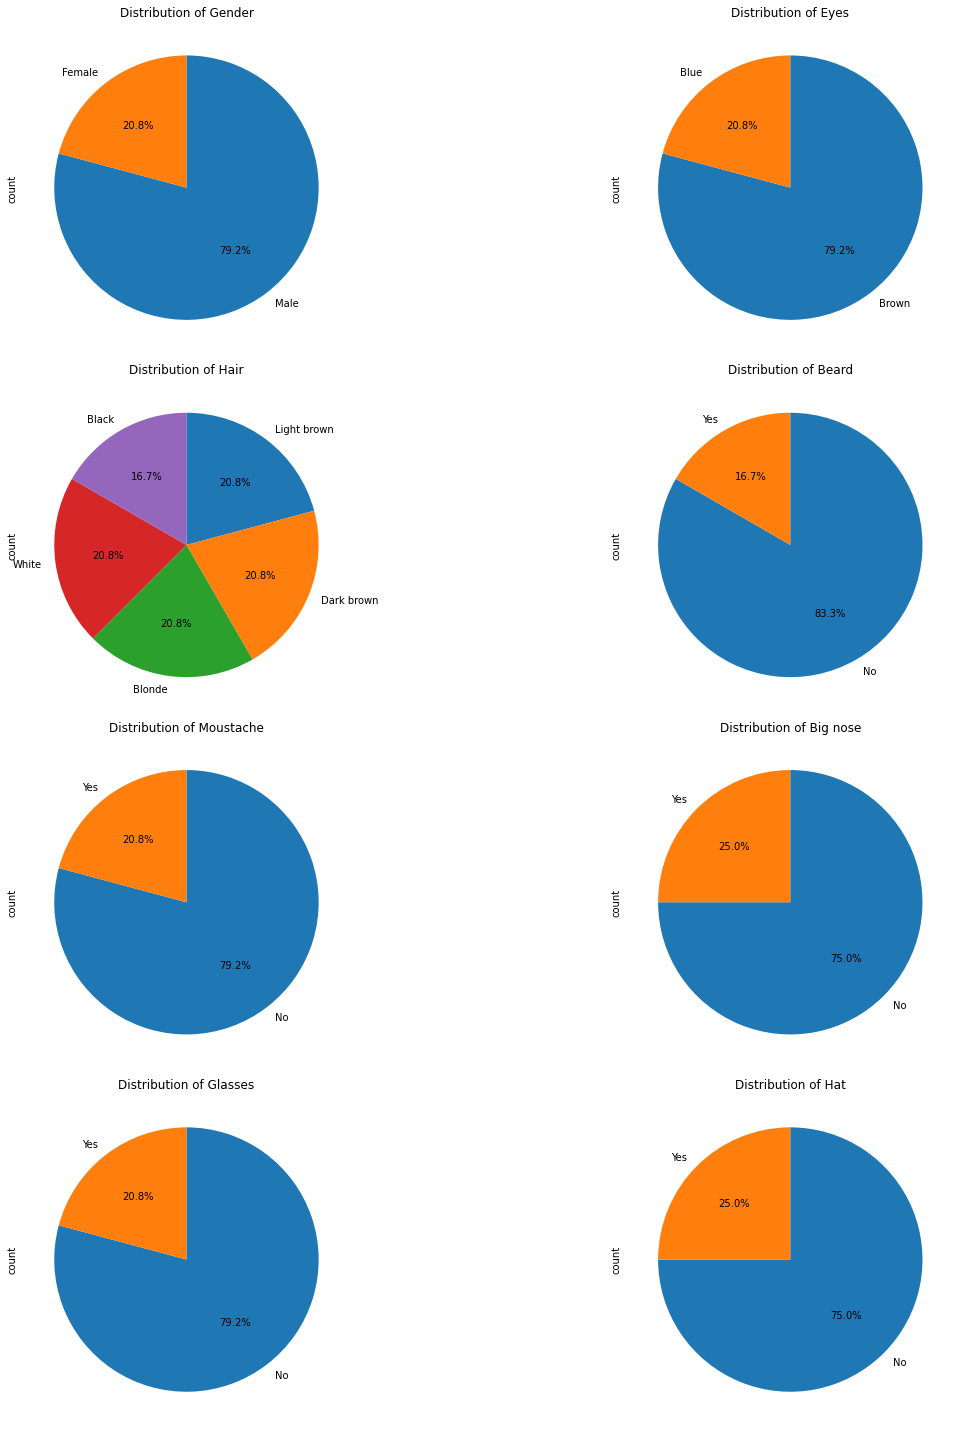

,count
Gender,
Male,19
Female,5


,count
Eyes,
Brown,19
Blue,5


,count
Hair,
Light brown,5
Dark brown,5
Blonde,5
White,5
Black,4


,count
Beard,
No,20
Yes,4


,count
Moustache,
No,19
Yes,5


,count
Big nose,
No,18
Yes,6


,count
Glasses,
No,19
Yes,5


,count
Hat,
No,18
Yes,6


In [ ]:
features = table.columns[1:]  # no 'name' column
feature_value_counts = {}

for feature in features:
    feature_value_counts[feature] = table[feature].value_counts()

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
for i, feature in enumerate(features):
    counts = feature_value_counts[feature]
    counts.plot.pie(ax=axes[i // 2][i % 2], autopct='%1.1f%%', startangle=90, counterclock=False)
    axes[i // 2][i % 2].set_title(f'Distribution of {feature}')
    axes[i // 2][i % 2].set_facecolor('white')

plt.tight_layout()
plt.show()


for feature in features:
    fvc = pd.DataFrame(feature_value_counts[feature])
    # show pandas table
    display(fvc)

We should aim to binary search. We need to select the percentage closest to $50\%$*. In fact, for a group of $24$ people, if (ideally) I can split the starting set into two equal subsets at each round, I need $log_2 (24) \approx 4.58 \rightarrow 5$.
$$24 \rightarrow 12 \rightarrow 6 \rightarrow 3 \rightarrow 2 \ \text{(worst case)}\rightarrow \text{wrong choice} \rightarrow \text{win}$$

Notice that after $4$ rounds, I've arrived at the subset of cardinality $2$, but there's no reason to ask another question to exclude one of them, because there's $0.5$ chance of winning directly.

\* $$E[n_{t+1}] = p n_{t,yes} + (1-p) n_{t,no} = p^2 n_t + (1-p)^2 n_t = (1 + 2p^2 - 2p) n_t$$

This formula is the expected number of rows in the $t+1$ round where i asked a question with $p$ probability. $n_th$ is the number of total rows in $t$-th round and $n_{t,yes}$/$n_{t,no}$ is the number of total rows where the answer is `yes`/`no`.

The minimum value of $E[n_{t+1}](p)$ is when $p = 0.5$.

In [127]:
def heatmap(data, row, col, ax):
    gender = data[row].unique()
    eye = data[col].unique()
    feature_matrix = pd.DataFrame(0, index=gender, columns=eye, dtype=int)
    for eye_color in eye:
        for g in gender:
            count = len(data[(data[row] == g) & (data[col] == eye_color)])
            feature_matrix.at[g, eye_color] = count
    sns.heatmap(feature_matrix, annot=True, cmap='YlGnBu', ax=ax)
    ax.set_title(f'{row} vs {col}')

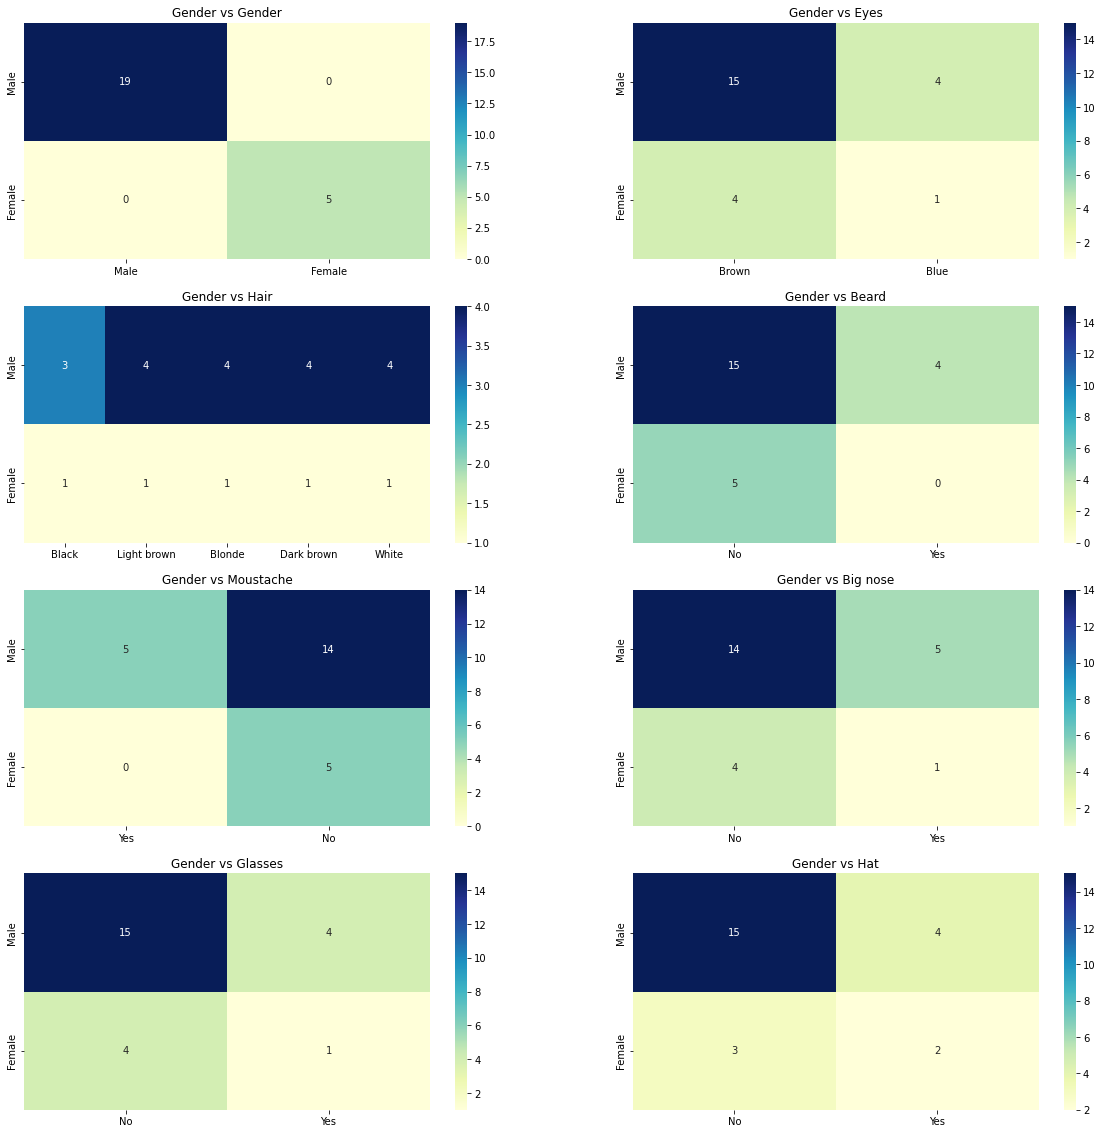

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
for i, col in enumerate(table.columns[1:]):
    heatmap(table, 'Gender', col, axes[i // 2][i % 2])
plt.show()

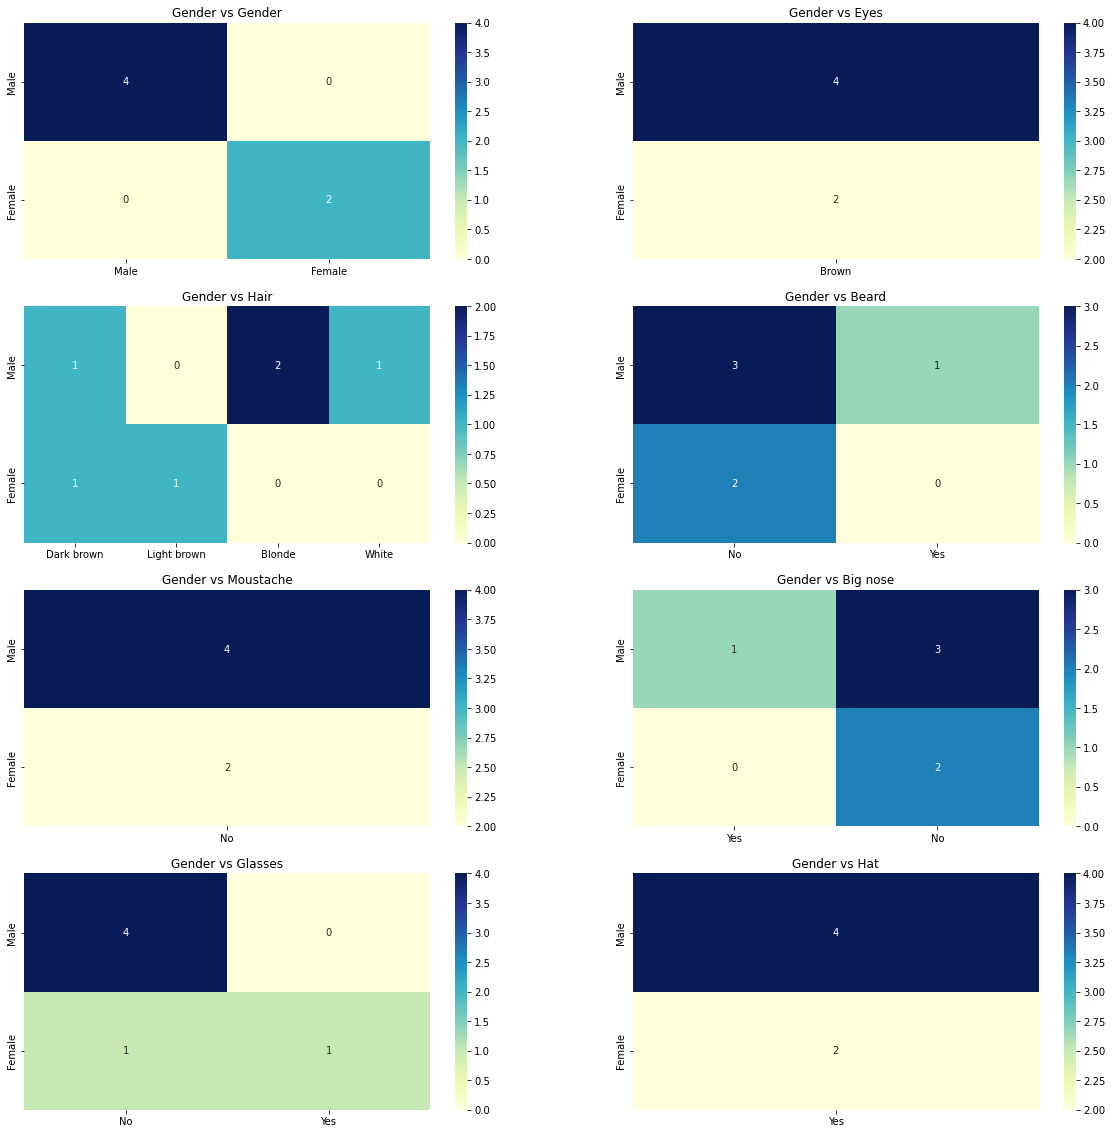

In [ ]:
# First filter: WITH HAT?

data_hat = table[table['Hat'] == person_row['Hat'].values[0]]
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
for i, col in enumerate(data_hat.columns[1:]):
    heatmap(data_hat, 'Gender', col, axes[i // 2][i % 2])
plt.show()

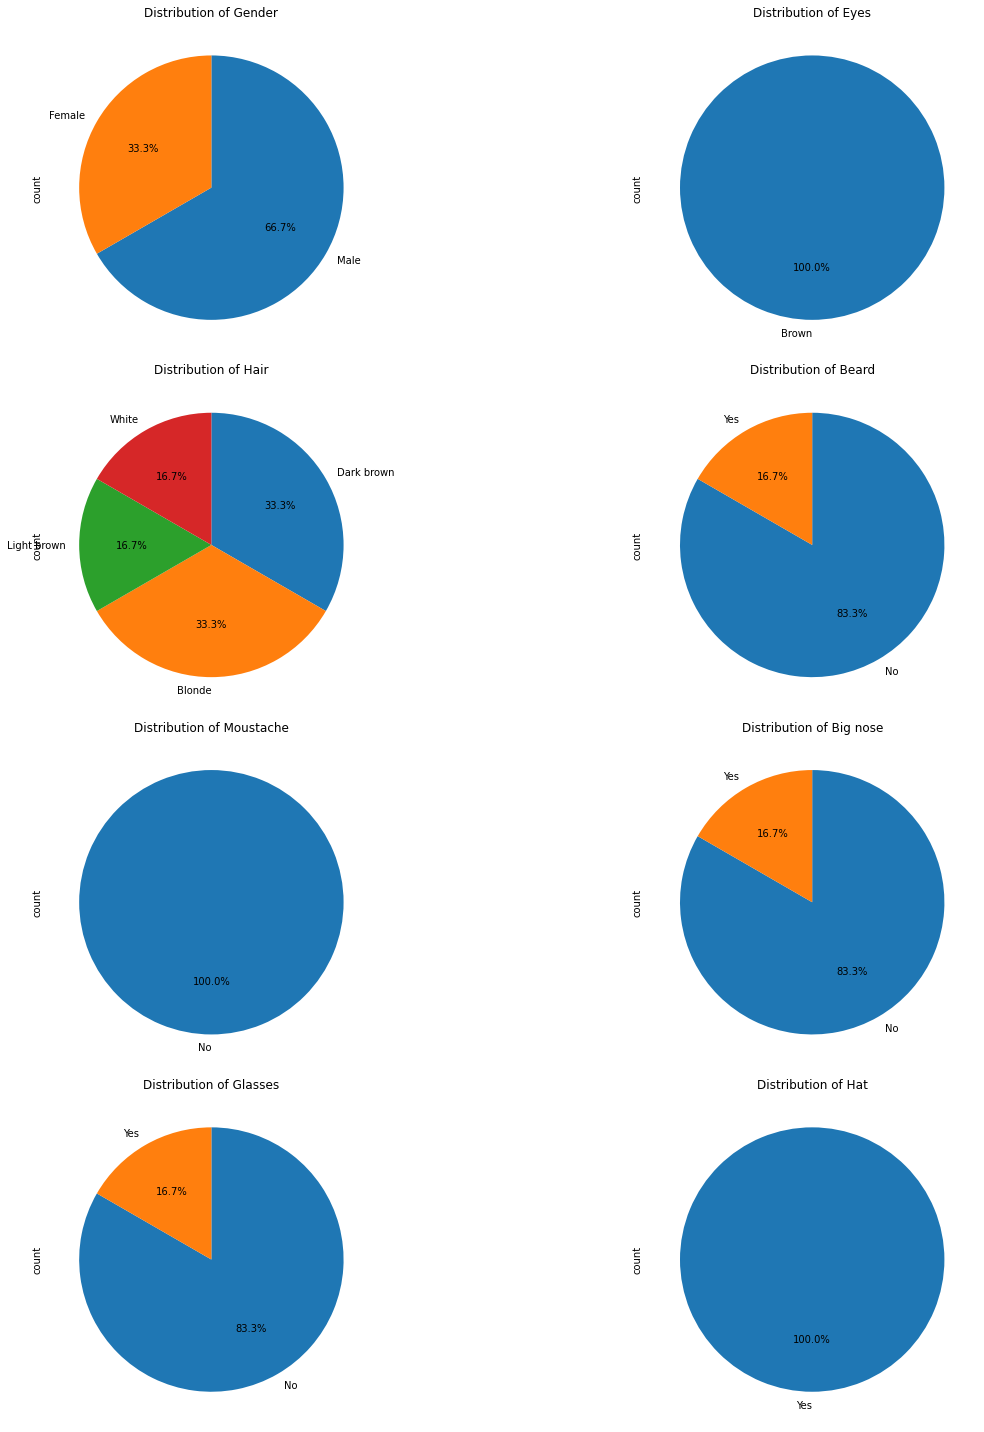

In [108]:
features = data_hat.columns[1:]  # no 'name' column
feature_value_counts = {}

for feature in features:
    feature_value_counts[feature] = data_hat[feature].value_counts()

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
for i, feature in enumerate(features):
    counts = feature_value_counts[feature]
    counts.plot.pie(ax=axes[i // 2][i % 2], autopct='%1.1f%%', startangle=90, counterclock=False)
    axes[i // 2][i % 2].set_title(f'Distribution of {feature}')
    axes[i // 2][i % 2].set_facecolor('white')

plt.tight_layout()
plt.show()

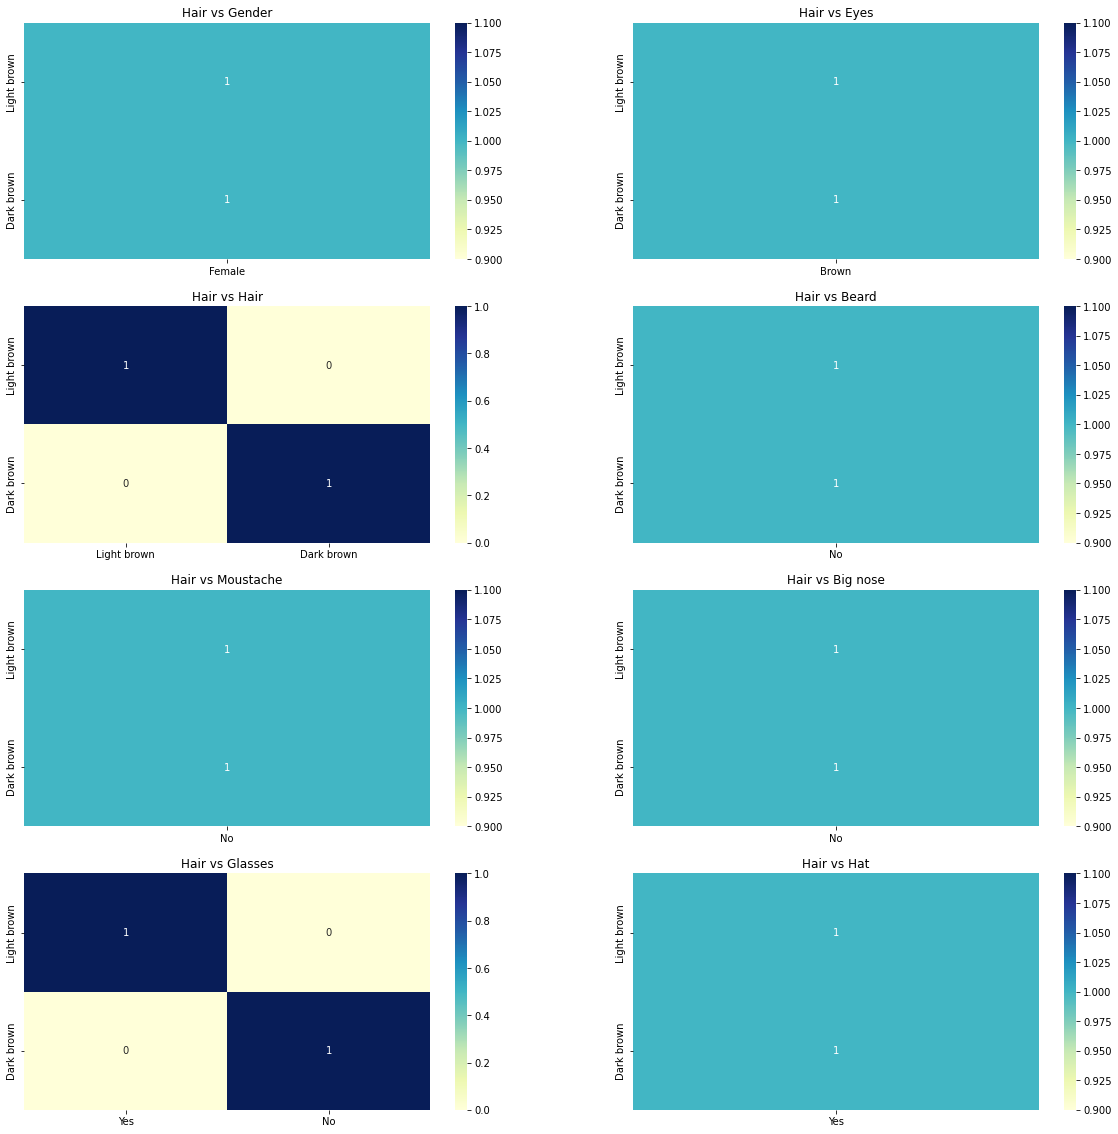

In [109]:
# second filter: FEMALE?
data_hat_gender = data_hat[data_hat['Gender'] == person_row['Gender'].values[0]]
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
for i, col in enumerate(data_hat_gender.columns[1:]):
    heatmap(data_hat_gender, 'Hair', col, axes[i // 2][i % 2])
plt.show()

We can see that the only graph with more than one column is `Hair vs Glasses` (of course `Hair vs Hair` is useless)

In [110]:
data_hat_gender

,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
7,Claire,Female,Brown,Light brown,No,No,No,Yes,Yes
14,Maria,Female,Brown,Dark brown,No,No,No,No,Yes


## Simulation

### Before simulation

Now let's find (with bruteforce) the best way to win (Hp: the opponent chose `Claire`)

Bruteforce is always possible. But is it always possible in a not really-really-long amount of time? Nope. Let's find out the number of question in an approximated way.

Let's ignore the questions about hair (when you are more than 2 classes).

Making a question about gender, about eyes, about beard, about moustache, about big nose, about glasses and about hat assume that we know every properties except hair. We know for sure that every character has, at least, one different property. So we should have a max number of $5$ people after $7$ questions. Then you have to ask for every hair color (a max of $4$ questions) $\rightarrow 11$ questions. 

There is an important question before... Is hair color column useful?

In [18]:
table_with_no_hair_color = table.drop(columns=['Hair', 'Name'])
pd.set_option('future.no_silent_downcasting', True)
table_with_no_hair_color.replace({
    'Gender': {'Male': 1, 'Female': 0},
    'Eyes': {'Brown': 1, 'Blue': 0},
    'Beard': {'Yes': 1, 'No': 0},
    'Moustache': {'Yes': 1, 'No': 0},
    'Big nose': {'Yes': 1, 'No': 0},
    'Glasses': {'Yes': 1, 'No': 0},
    'Hat': {'Yes': 1, 'No': 0},
    }, inplace=True)
table_with_no_hair_color['bin'] = table_with_no_hair_color.apply(lambda row: ''.join(row.astype(str)), axis=1)
table_with_no_hair_color.sort_values('bin', inplace=True)
display(table_with_no_hair_color)
table_with_no_hair_color['bin'].value_counts()

,Gender,Eyes,Beard,Moustache,Big nose,Glasses,Hat,bin
2,0,0,0,0,0,0,0,0000000
22,0,1,0,0,0,0,0,0100000
14,0,1,0,0,0,0,1,0100001
7,0,1,0,0,0,1,1,0100011
3,0,1,0,0,1,0,0,0100100
23,1,0,0,0,0,1,0,1000010
20,1,0,0,0,1,0,0,1000100
17,1,0,0,0,1,0,0,1000100
1,1,0,0,1,0,0,0,1001000
10,1,1,0,0,0,0,0,1100000


bin
1100010    3
1100001    2
1110000    2
1000100    2
1101000    2
0000000    1
0100000    1
1000010    1
0100001    1
0100011    1
1100000    1
1001000    1
0100100    1
1100100    1
1100101    1
1101100    1
1110001    1
1111000    1
Name: count, dtype: int64

So... yeah, hair color is useful in some cases but not that useful because with $2$ people you can just ask for person `A`. In case you missed, just win go for person `B`. In the $3$-characters case maybe a valid question can save us a round (with lucky).

### Starting simulation (no bruteforce)

In [29]:
def find_optimal_question(table):
    features = table.columns[1:]  # no 'name' column
    total_counts = len(table)
    min_perc = 0.51 # > 0.5
    min_perc_val = None
    for feature in features:
        for key, value in table[feature].value_counts().to_dict().items():
            if abs(value / total_counts - 0.5) < min_perc:
                min_perc = abs(value / total_counts - 0.5)
                min_perc_val = (feature, key, value / total_counts)
    return min_perc_val

In [40]:
question_asked = []
answer_history = []
red_percentage = []

curr_table = table.copy()

while len(curr_table) > 2:
    feature, key, percentage, *_ = find_optimal_question(curr_table)
    question_asked.append((feature, key))
    answer = 'Yes' if person_row[feature].values[0] == key else 'No'
    answer_history.append(answer)
    if answer == 'Yes':
        red_percentage.append(percentage)
    else:
        red_percentage.append(1 - percentage)
    curr_table = curr_table[curr_table[feature] == key] if answer == 'Yes' else curr_table[curr_table[feature] != key]

print(question_asked)
print(answer_history)
print(red_percentage)
display(curr_table)

[('Big nose', 'No'), ('Hair', 'Blonde'), ('Hair', 'Light brown'), ('Gender', 'Male')]
['Yes', 'No', 'Yes', 'No']
[0.75, 0.7222222222222222, 0.3076923076923077, 0.25]


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
7,Claire,Female,Brown,Light brown,No,No,No,Yes,Yes


### Simulation with every character (not bruteforce)

In [64]:
num_questions = 0
avg_probabilistic_questions = 0

for id in range(len(table)):
    person_row = table.iloc[id]
    question_asked = []
    answer_history = []
    red_percentage = []

    curr_table = table.copy()

    while len(curr_table) > 2:
        feature, key, percentage, *_ = find_optimal_question(curr_table)
        question_asked.append((feature, key))
        num_questions += 1
        answer = 'Yes' if person_row[feature] == key else 'No'
        answer_history.append(answer)
        if answer == 'Yes':
            red_percentage.append(percentage)
        else:
            red_percentage.append(1 - percentage)
        curr_table = curr_table[curr_table[feature] == key] if answer == 'Yes' else curr_table[curr_table[feature] != key]
    if len(curr_table) == 2:
        avg_probabilistic_questions += 0.5  # on average, it takes 0.5 more question to distinguish between 2 people

    print(question_asked)
    print(answer_history)
    print(red_percentage)
    display(curr_table)

[('Big nose', 'No'), ('Hair', 'Blonde'), ('Hair', 'Light brown'), ('Hair', 'White'), ('Hair', 'Black'), ('Eyes', 'Brown')]
['Yes', 'No', 'No', 'No', 'Yes', 'Yes']
[0.75, 0.7222222222222222, 0.6923076923076923, 0.5555555555555556, 0.6, 0.6666666666666666]


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
0,Alex,Male,Brown,Black,No,Yes,No,No,No
18,Philip,Male,Brown,Black,Yes,No,No,No,No


[('Big nose', 'No'), ('Hair', 'Blonde'), ('Hair', 'Light brown'), ('Gender', 'Male'), ('Eyes', 'Brown')]
['Yes', 'No', 'Yes', 'Yes', 'No']
[0.75, 0.7222222222222222, 0.3076923076923077, 0.75, 0.33333333333333337]


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
1,Alfred,Male,Blue,Light brown,No,Yes,No,No,No


[('Big nose', 'No'), ('Hair', 'Blonde'), ('Hat', 'No'), ('Gender', 'Male')]
['Yes', 'Yes', 'Yes', 'No']
[0.75, 0.2777777777777778, 0.6, 0.33333333333333337]


...

,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
16,Paul,Male,Brown,White,No,No,No,Yes,No
21,Sam,Male,Brown,White,No,No,No,Yes,No


[('Big nose', 'No'), ('Hair', 'Blonde'), ('Hair', 'Light brown'), ('Hair', 'White'), ('Glasses', 'No')]
['Yes', 'No', 'No', 'Yes', 'Yes']
[0.75, 0.7222222222222222, 0.6923076923076923, 0.4444444444444444, 0.5]


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
11,George,Male,Brown,White,No,No,No,No,Yes
22,Susan,Female,Brown,White,No,No,No,No,No


[('Big nose', 'No'), ('Hair', 'Blonde'), ('Hair', 'Light brown'), ('Hair', 'White'), ('Hair', 'Black'), ('Eyes', 'Brown')]
['Yes', 'No', 'No', 'No', 'Yes', 'No']
[0.75, 0.7222222222222222, 0.6923076923076923, 0.5555555555555556, 0.6, 0.33333333333333337]


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
23,Tom,Male,Blue,Black,No,No,No,Yes,No


In [73]:
print(f'Average number of questions per character (arriving at size 2 table): {num_questions / len(table):.4f}')
print(f'Average number of questions per character (guessing  the  character): {num_questions / len(table) + 1 + avg_probabilistic_questions / len(table):.4f}')
print(f'Average number of questions per character (guessing with worst case): {num_questions / len(table) + 1 + 2*avg_probabilistic_questions / len(table):.4f}')

Average number of questions per character (arriving at size 2 table): 4.2917
Average number of questions per character (guessing  the  character): 5.6667
Average number of questions per character (guessing with worst case): 6.0417


### Simulation on `Claire` (bruteforce)

In [76]:
person_row = table[table['Name'] == RANDOM_PERSON].iloc[0]

question_asked = []
answer_history = []
red_percentage = []

curr_table = table.copy()

features = table.columns[1:]

while len(curr_table) > 2:
    min_len = len(curr_table)
    min_question = None
    for feature in features:
        keys = table[features].mode().iloc[0]
        for key in keys:
            curr_question = (feature, key)
            answer = 'Yes' if person_row[feature] == key else 'No'
            test_table = curr_table[curr_table[feature] == key] if answer == 'Yes' else curr_table[curr_table[feature] != key]
            if len(test_table) < min_len:
                min_len = len(test_table)
                min_question = curr_question
                min_table = test_table
                min_answer = answer    
    question_asked.append(min_question)
    answer_history.append(min_answer)
    red_percentage.append(min_len / len(table))
    curr_table = min_table

print(question_asked)
print(answer_history)
print(red_percentage)
display(curr_table)

[('Gender', 'Male'), ('Glasses', 'No')]
['No', 'No']
[0.20833333333333334, 0.041666666666666664]


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
7,Claire,Female,Brown,Light brown,No,No,No,Yes,Yes


### Simulation with every character (bruteforce)

In [88]:
curr_table = table.copy()
features = table.columns[1:]

min_question = None
min_aggregate_len = float('inf')
for feature in features:
    keys = table[features].mode().iloc[0]
    for key in keys:
        aggregate_len = 0
        curr_question = (feature, key)
        for id in range(len(table)):
            person_row = table.iloc[id]
            answer = 'Yes' if person_row[feature] == key else 'No'
            test_table = curr_table[curr_table[feature] == key] if answer == 'Yes' else curr_table[curr_table[feature] != key]
            aggregate_len += len(test_table)
        if aggregate_len < min_aggregate_len:
            min_aggregate_len = aggregate_len
            min_question = curr_question
print(f'Optimal question to ask initially is: {min_question} with table length on average: {min_aggregate_len/len(table):.2f} ({-(1 - min_aggregate_len/len(table)/len(table)):.1%})')

Optimal question to ask initially is: ('Big nose', 'No') with table length on average: 15.00 (-37.5%)


Now I want to simulate that player $1$ did that question and find the best question to use after that. (And so on.)

In [105]:
curr_table = table.copy()
features = table.columns[1:]

min_question = None
question_asked = []
min_aggregate_len = float('inf')
min_tables = None
tables_log = []
curr_question_number = 0
last_table_len = len(table)

MAX_QUESTIONS = 8

for curr_question_number in range(MAX_QUESTIONS):
    for feature in features:
        keys = table[features].mode().iloc[0]
        for key in keys:
            aggregate_len = 0
            curr_question = (feature, key)
            tables = [None for _ in range(len(table))]
            for id in range(len(table)):
                person_row = table.iloc[id]
                answer = 'Yes' if person_row[feature] == key else 'No'
                if curr_question_number > 0:
                    curr_table = tables_log[curr_question_number-1][id]
                test_table = curr_table[curr_table[feature] == key] if answer == 'Yes' else curr_table[curr_table[feature] != key]
                tables[id] = test_table
                aggregate_len += len(test_table)
            if aggregate_len < min_aggregate_len:
                min_aggregate_len = aggregate_len
                min_question = curr_question
                min_tables = tables
    question_asked.append(min_question)
    tables_log.append(min_tables)
    print(f'Optimal question to ask in round {curr_question_number+1} is: {min_question} with table length on average: {min_aggregate_len/len(table):.2f} ({-(1 - min_aggregate_len/len(table)/last_table_len):.1%})')
    last_table_len = min_aggregate_len/len(table)


Optimal question to ask in round 1 is: ('Big nose', 'No') with table length on average: 15.00 (-37.5%)
Optimal question to ask in round 2 is: ('Hat', 'No') with table length on average: 9.17 (-38.9%)
Optimal question to ask in round 3 is: ('Moustache', 'No') with table length on average: 5.83 (-36.4%)
Optimal question to ask in round 4 is: ('Glasses', 'No') with table length on average: 3.83 (-34.3%)
Optimal question to ask in round 5 is: ('Eyes', 'Brown') with table length on average: 2.67 (-30.4%)
Optimal question to ask in round 6 is: ('Beard', 'No') with table length on average: 1.92 (-28.1%)
Optimal question to ask in round 7 is: ('Hair', 'Blonde') with table length on average: 1.50 (-21.7%)
Optimal question to ask in round 8 is: ('Gender', 'Male') with table length on average: 1.25 (-16.7%)


### Using these questions to guess

In [106]:
question_asked

[('Big nose', 'No'),
 ('Hat', 'No'),
 ('Moustache', 'No'),
 ('Glasses', 'No'),
 ('Eyes', 'Brown'),
 ('Beard', 'No'),
 ('Hair', 'Blonde'),
 ('Gender', 'Male')]

In [107]:
QUESTIONS = [
    ('Big nose', 'No'),
    ('Hat', 'No'),
    ('Moustache', 'No'),
    ('Glasses', 'No'),
    ('Eyes', 'Brown'),
    ('Beard', 'No'),
    ('Hair', 'Blonde'),
    ('Gender', 'Male')
]

In [121]:
def play_game():
    real_random_person = random.choice(table['Name'].tolist())
    real_random_row = table[table['Name'] == real_random_person].iloc[0]
    question_asked = []
    answer_history = []
    red_percentage = []

    curr_table = table.copy()

    for feature, key in QUESTIONS:
        if len(curr_table[curr_table[feature] == key]) == 0 or len(curr_table[curr_table[feature] != key]) == 0:
            continue  # skip questions that don't split the table
        question_asked.append((feature, key))
        answer = 'Yes' if real_random_row[feature] == key else 'No'
        answer_history.append(answer)
        if answer == 'Yes':
            red_percentage.append(len(curr_table[curr_table[feature] == key]) / len(curr_table))
            curr_table = curr_table[curr_table[feature] == key]
        else:
            red_percentage.append(len(curr_table[curr_table[feature] != key]) / len(curr_table))
            curr_table = curr_table[curr_table[feature] != key]
        if len(curr_table) <= 2:
            break
    return question_asked, answer_history, red_percentage, curr_table, real_random_person

In [129]:
question_asked, answer_history, red_percentage, curr_table, real_random_person = play_game()

print('Q&A history:')
for question, answer in zip(question_asked, answer_history):
    print(f' - {question[0]} == {question[1]}')
    print(f' - {answer}')
print('Red percentage:')
for percentage in red_percentage:
    print(f' - {percentage:.2%}')
display(curr_table)
print(f'The random person is: {real_random_person}')

Q&A history:
 - Big nose == No
 - Yes
 - Hat == No
 - Yes
 - Moustache == No
 - No
 - Eyes == Brown
 - No
Red percentage:
 - 75.00%
 - 72.22%
 - 30.77%
 - 25.00%


,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
1,Alfred,Male,Blue,Light brown,No,Yes,No,No,No


The random person is: Alfred
